In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm

from configs.config import Config
from scripts.dataset import DishDataset, get_transforms, collate_fn
from scripts.model import MultimodalModel
from scripts.utils import seed_everything, set_requires_grad, train_one_epoch, evaluate, calculate_metrics


In [ ]:
cfg = Config()
seed_everything(cfg.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Этап 1. Проведите исследовательский анализ (EDA)

In [3]:
dish_df = pd.read_csv("data/dish.csv")
ingredients_df = pd.read_csv("data/ingredients.csv")

In [4]:
display(dish_df.head(5))
display(dish_df.info())
display(ingredients_df.head(5))
display(ingredients_df.info())

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


None

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


None

In [5]:
display(sum(dish_df.duplicated()))
display(dish_df.isnull().sum())

0

dish_id           0
total_calories    0
total_mass        0
ingredients       0
split             0
dtype: int64

Явных дубликатов нет.
Нет нулевых значений.

In [6]:
dish_df.describe()

,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


In [7]:
dish_df[dish_df["total_calories"] == 0]

,dish_id,total_calories,total_mass,ingredients,split
263,dish_1557861216,0.0,1.0,ingr_0000000423,test
2652,dish_1556575700,0.0,86.0,ingr_0000000423,train


In [8]:
ingredients_df[ingredients_df["id"]==423]

,id,ingr
422,423,plate only


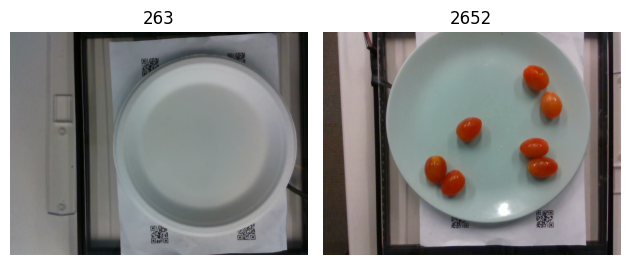

In [9]:
no_cal_dishes = dish_df[dish_df["total_calories"] == 0]
no_cal_dishes_list = list(no_cal_dishes["dish_id"])
fig, axes = plt.subplots(nrows=1, ncols=len(no_cal_dishes_list))
for i in range(len(no_cal_dishes_list)):
    image = Image.open(f"data/images/{no_cal_dishes_list[i]}/rgb.png")

    axes[i].imshow(image)
    axes[i].set_title(no_cal_dishes[no_cal_dishes["ingredients"] == list(no_cal_dishes["ingredients"])].index[i])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

При индексе 2652 явно ответ неверен, ибо количество ингридиентов, калорийность, а также сам ингридиент по смыслу не подходит(!=plate only). Значит нам необходимо удалить этот элемент.

In [10]:
dish_df = dish_df.drop(index=2652)

In [11]:
def box_plot_out(df, cols=None, ax=None):
    stand_still = True

    if cols is None:
        data = df
    else:
        data = df[cols]
    
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 8))
    else:
        stand_still = False
    
    labels = data.columns if hasattr(data, 'columns') else [data.name]
    ax.boxplot(data.values, tick_labels=labels)
    
    title = 'Range of feature meaning'
    if cols is not None:   
        title += f': {cols}'
    
    ax.set_title(title)
    ax.grid(True, axis='y')
    ax.tick_params(axis='x', rotation=90)
    
    if stand_still:
        plt.show()
        plt.close()
    
    return ax


In [12]:
def del_bool_cols(df):
    numeric_data = df.select_dtypes(include='number')
    
    return numeric_data.loc[:, ~numeric_data.isin([0, 1]).all()]

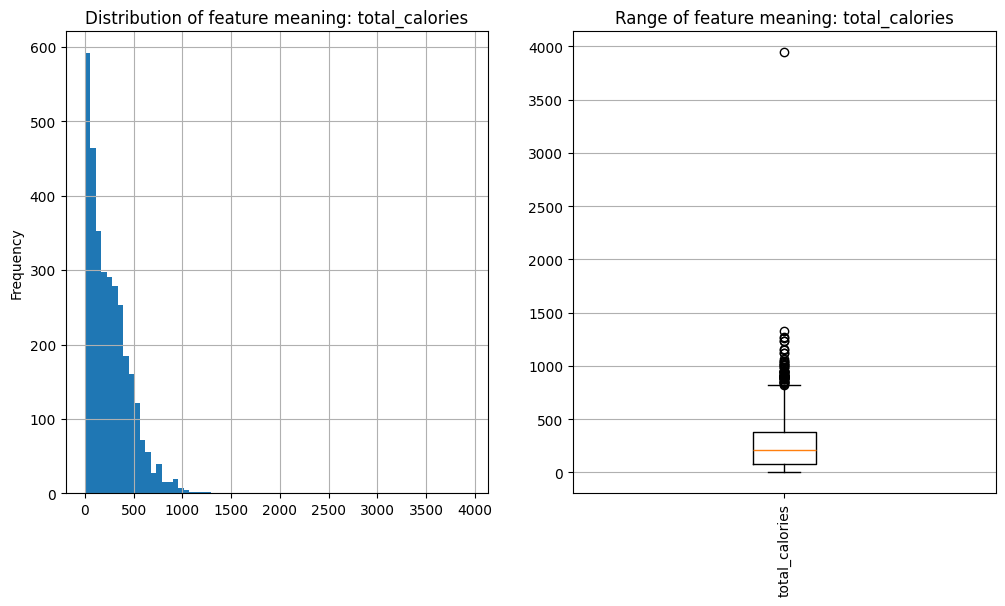

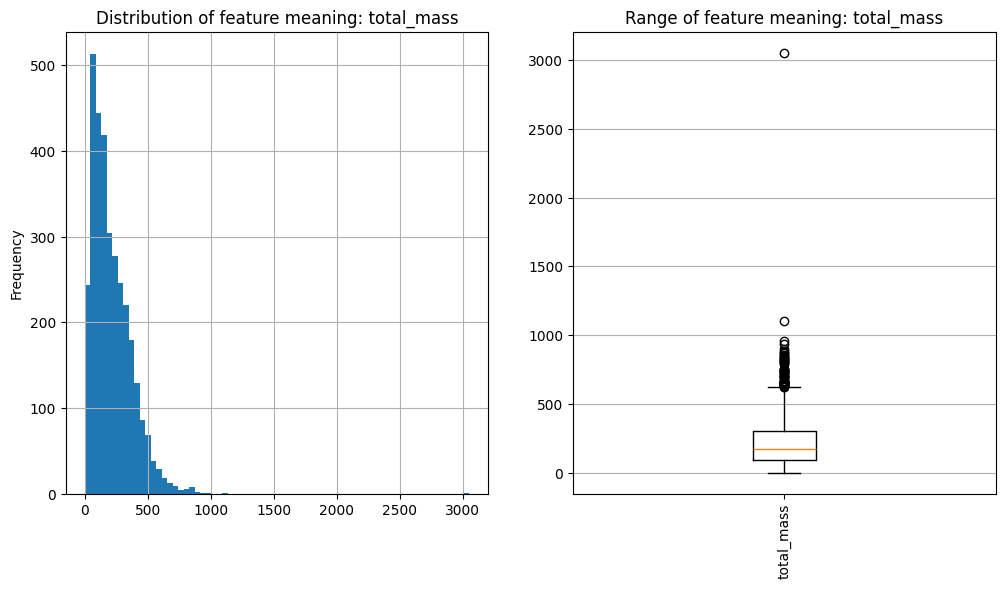

In [13]:
def emission_analysis(df):
    data = del_bool_cols(df)
    
    for col in data:
        _, axes = plt.subplots(figsize=(12, 6), nrows=1, ncols=2)
        
        data[col].plot(    
            kind='hist',
            ax=axes[0],
            bins=70,
            grid=True
        )
        
        axes[0].set_title(f'Distribution of feature meaning: {col}')
        
        box_plot_out(data, col, axes[1])
        
        plt.show()
        plt.close()

emission_analysis(dish_df)

Тут у нас есть 1 явный выброс в двух случаях(вероятно один и тот же, но мы это проверим), также я бы посмотрел на значение массы более 1000, там есть 1 значение похожее на выброс.

In [14]:
display(dish_df[dish_df["total_mass"] > 1000])
display(dish_df[dish_df["total_calories"] > 1500])

,dish_id,total_calories,total_mass,ingredients,split
328,dish_1561739805,696.363525,1102.0,ingr_0000000040;ingr_0000000027;ingr_000000001...,train
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train


,dish_id,total_calories,total_mass,ingredients,split
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train


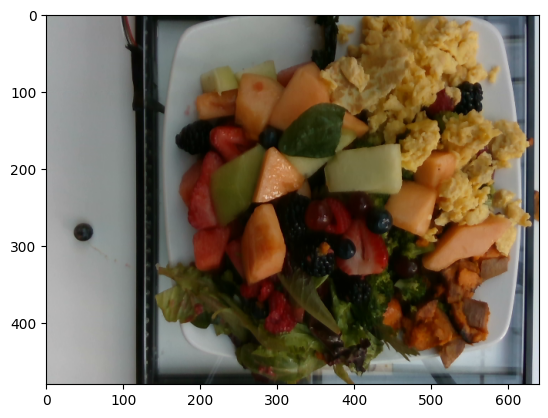

In [15]:
plt.figure()

image = Image.open("data/images/dish_1561739805/rgb.png")

plt.imshow(image)
plt.show()

In [16]:
dish_df = dish_df.drop(index=1518)

Так как на изображении огромное количество еды, я оставлю этот случай, модель научиться лучше воспринимать редкие варианты. А вот значение с массой +-3000 и калорийностью +-4000 - будет удалено, ибо оно слишком сильно отличается от остальных выборки.

### Data Leakage

Теперь я хочу провести проверку на утечки данных(чтобы не было дубликатов между train и test подвыборками). А также я посмотрю на соответсвие ингридиентов в dish_df и ingredients_df, вдруг в ingredients нет компонентов из первой таблицы.

In [17]:
extracted_ids = set(dish_df["ingredients"].str.findall(r'ingr_0*(\d+)').explode().map(int))
valid_set = set(ingredients_df["id"])

all_common_check = extracted_ids.issubset(valid_set)

print(f"Все элементы на месте? {'Да' if all_common_check else 'Нет'}")
print(f"Уникальных в основной: {len(extracted_ids)}")
print(f"Найдено в расшифровке: {len(extracted_ids & valid_set)}")

Все элементы на месте? Да
Уникальных в основной: 200
Найдено в расшифровке: 200


In [18]:
len(ingredients_df["ingr"].unique())

552

In [19]:
ingredients_df[ingredients_df["ingr"].duplicated(keep=False)]

,id,ingr
230,231,deprecated
452,453,deprecated
457,458,deprecated
469,470,deprecated


In [20]:
ids_to_find = [230, 452, 457, 469]

pattern = '|'.join([rf'\b{i}\b' for i in ids_to_find])

bad_rows_mask = dish_df['ingredients'].astype(str).str.contains(pattern)

found_rows = dish_df[bad_rows_mask]

print(f"Найдено строк с индексами {ids_to_find}: {len(found_rows)}")
display(found_rows)

Найдено строк с индексами [230, 452, 457, 469]: 0


,dish_id,total_calories,total_mass,ingredients,split


У нас все значения ингридиентов из основной таблицы присутствуют в ingridients.csv, а также я нашел значения deprecated в ingridients.csv, однако их нет в основной таблице, поэтому переживать не о чем.

Теперь проверка на утечку:

In [21]:
data_leak = dish_df.drop(columns="split").duplicated().sum()

print(f"Утекло данных: {data_leak}")

Утекло данных: 0


Тут мы закончили. Теперь я визуализирую данные нескольких фотографий, чтобы определиться с аугментацией(предварительно: не стоит менять цветовые каналы, а также не стоит использовать dropout для вырезания больших квадратов, однако она модет быть полезна, чтобы, например, нейросеть не полагалась на форму тарелки, обязательно стоит: повернуть по-разному значения, изменить яркость, добавить немного шума, слегка изменить контрастность)

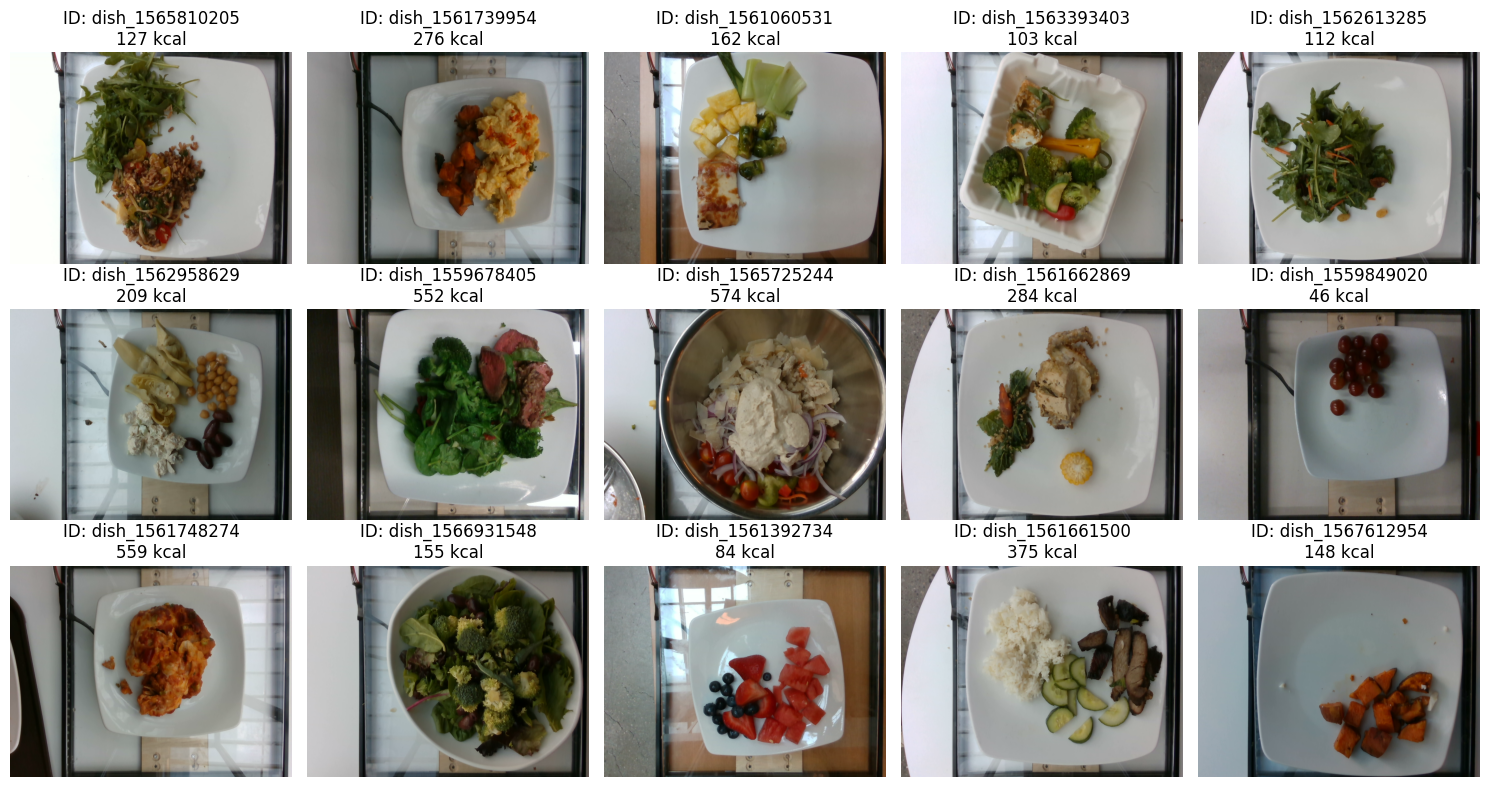

In [22]:
random_samples = dish_df.sample(n=15, replace=False, random_state=42)

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 8))
axes = axes.flatten()

for i, (idx, row) in enumerate(random_samples.iterrows()):
    dish_id = row["dish_id"]
    calories = row["total_calories"]

    img_path = f"data/images/{dish_id}/rgb.png" 
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(f"ID: {dish_id}\n{calories:.0f} kcal")
    
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Вроде все адекватно! Можно двигаться дальше! 

**Из метрик буду использовать**:
 
 MAE(необходимо по условию).

 RMSE, чтобы проверить есть ли очень грубые ошибки на редких блюдах.

 MAPE, у нас много каких-то салатов, фруктов, но есть и полноценные блюда, нам необходимо понимать, что ошибка в 50 ккал для условного риса с курицей, менее значительна, чем для ягод или фруктов.

 R^2(возможно, но не вижу особо смысла в коэффициенте детерминации в этой задаче)

---

Теперь сохраним измененный csv файл и перейдем к пайплайну обучения!

In [23]:
dish_df.to_csv("data/dish_eda.csv")

# Этап 2. Реализуйте пайплайн обучения

In [24]:
df = pd.read_csv("data/dish_eda.csv")

train_all = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

train_df, val_df = train_test_split(train_all, test_size=0.15, random_state=cfg.SEED)

train_df.to_csv(cfg.TRAIN_DF_PATH, index=False)
val_df.to_csv(cfg.VAL_DF_PATH, index=False)
test_df.to_csv(cfg.TEST_DF_PATH, index=False)

print(f"Данные готовы: Train {len(train_df)}, Val {len(val_df)}, Test {len(test_df)}")

Данные готовы: Train 2340, Val 413, Test 507


In [25]:
tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)

train_ds = DishDataset(cfg, get_transforms(cfg, "train"), ds_type="train")
val_ds = DishDataset(cfg, get_transforms(cfg, "val"), ds_type="val")

train_loader = DataLoader(
    train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, 
    collate_fn=partial(collate_fn, tokenizer=tokenizer),
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, 
    collate_fn=partial(collate_fn, tokenizer=tokenizer),
)

model = MultimodalModel(cfg).to(device)

set_requires_grad(model.text_model, cfg.TEXT_MODEL_UNFREEZE, verbose=True)
set_requires_grad(model.image_model, cfg.IMAGE_MODEL_UNFREEZE, verbose=True)

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Разморожен слой: encoder.layer.11.attention.self.query.weight
Разморожен слой: encoder.layer.11.attention.self.query.bias
Разморожен слой: encoder.layer.11.attention.self.key.weight
Разморожен слой: encoder.layer.11.attention.self.key.bias
Разморожен слой: encoder.layer.11.attention.self.value.weight
Разморожен слой: encoder.layer.11.attention.self.value.bias
Разморожен слой: encoder.layer.11.attention.output.dense.weight
Разморожен слой: encoder.layer.11.attention.output.dense.bias
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.11.intermediate.dense.weight
Разморожен слой: encoder.layer.11.intermediate.dense.bias
Разморожен слой: encoder.layer.11.output.dense.weight
Разморожен слой: encoder.layer.11.output.dense.bias
Разморожен слой: encoder.layer.11.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.output.LayerNorm.bias
Разморожен слой: pooler.dense.weight
Раз

# Этап 3. Обучение модели

In [ ]:
criterion = nn.L1Loss()

optimizer_parameters = [
    {'params': model.text_model.parameters(), 'lr': cfg.TEXT_LR},
    {'params': model.image_model.parameters(), 'lr': cfg.IMAGE_LR},
    {
        'params': list(model.classifier.parameters()) + \
                  list(model.text_proj.parameters()) + \
                  list(model.image_proj.parameters()),
        'lr': cfg.CLASSIFIER_LR
    }
]

optimizer = AdamW(optimizer_parameters, weight_decay=0.01)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-7
)

best_mae = float('inf')

print(f"Обучение началось | Device: {device}")

for epoch in range(cfg.EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    
    val_loss, mae, rmse, mape = evaluate(model, val_loader, criterion, device)
    
    scheduler.step(mae)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n[Эпоха {epoch+1}/{cfg.EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | LR: {current_lr:.2e}")
    
    if mae < best_mae:
        best_mae = mae
        torch.save(model.state_dict(), cfg.SAVE_PATH)
        print(f"Модель лучше предыдущей | MAE: {mae:.2f} | Сохранено: {cfg.SAVE_PATH}")

    print("-" * 50)

print(f"Обучение завершено | MAE best: {best_mae:.2f}")

Обучение началось | Device: cuda


Training:   0%|          | 0/74 [00:00<?, ?it/s]


[Эпоха 1/40]
Train Loss: 248.5883 | Val Loss: 242.3498
MAE: 242.54 | RMSE: 315.26 | MAPE: 91.07% | LR: 3.00e-05
Модель лучше предыдущей | MAE: 242.54 | Сохранено: best_model.pth
--------------------------------------------------


Training:   0%|          | 0/74 [00:00<?, ?it/s]


[Эпоха 2/40]
Train Loss: 242.2029 | Val Loss: 234.9339
MAE: 235.12 | RMSE: 309.13 | MAPE: 89.31% | LR: 3.00e-05
Модель лучше предыдущей | MAE: 235.12 | Сохранено: best_model.pth
--------------------------------------------------


...


[Эпоха 38/40]
Train Loss: 48.5073 | Val Loss: 46.8819
MAE: 46.95 | RMSE: 88.42 | MAPE: 21.29% | LR: 3.00e-05
Модель лучше предыдущей | MAE: 46.95 | Сохранено: best_model.pth
--------------------------------------------------


Training:   0%|          | 0/74 [00:00<?, ?it/s]


[Эпоха 39/40]
Train Loss: 47.2277 | Val Loss: 48.7299
MAE: 48.82 | RMSE: 88.65 | MAPE: 22.55% | LR: 3.00e-05
--------------------------------------------------


Training:   0%|          | 0/74 [00:00<?, ?it/s]


[Эпоха 40/40]
Train Loss: 48.3271 | Val Loss: 48.6370
MAE: 48.70 | RMSE: 89.23 | MAPE: 21.69% | LR: 3.00e-05
--------------------------------------------------
Обучение завершено | MAE best: 46.95


### На валидационной выборке достигнуто удовлетворающее значение. Перейдем к тестовой.

# Этап 4. Валидация качества

In [ ]:
test_ds = DishDataset(cfg, transforms=get_transforms(cfg, "test"), ds_type="test") 

test_loader = DataLoader(
    test_ds, 
    batch_size=cfg.BATCH_SIZE, 
    shuffle=False, 
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)


model = MultimodalModel(cfg).to(device)
model.load_state_dict(torch.load(cfg.SAVE_PATH, map_location=device))
model.eval()

print(f"Модель загружена {cfg.SAVE_PATH} | Финальный тест")

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        image = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        mass = batch['mass'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, mask, image, mass).squeeze()
        
        all_preds.append(outputs.cpu())
        all_targets.append(labels.cpu())

preds = torch.cat(all_preds)
targets = torch.cat(all_targets)

test_mae, test_rmse, test_mape = calculate_metrics(preds, targets)

print("\n" + "="*30)
print("test results:")
print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAPE: {test_mape:.2f}%")
print("="*30)

results_df = pd.DataFrame({
    'Real Calories': targets.numpy(),
    'Predicted Calories': preds.numpy(),
    'Error': np.abs(targets.numpy() - preds.numpy())
})

print("\nПримеры предсказаний:")
print(results_df.head(10))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена best_model.pth | Финальный тест


Testing:   0%|          | 0/13 [00:00<?, ?it/s]


test results:
MAE:  46.95
RMSE: 88.42
MAPE: 21.29%

Примеры предсказаний:
   Real Calories  Predicted Calories       Error
0      39.599998           26.338940   13.261059
1     209.934982          281.425720   71.490738
2     249.819977          299.598419   49.778442
3     263.749023           91.217728  172.531296
4     345.333008          272.286621   73.046387
5     747.747803          535.348572  212.399231
6       7.000000            6.962996    0.037004
7     124.973000          116.364799    8.608200
8      33.660000           23.085289   10.574711
9     173.680008          153.238754   20.441254


На тесте также проходит результаты. Можно загружать артфект обученной модели в продакшн-сервер.